# Phase 5.5: ICC (Intraclass Correlation Coefficient) Analysis

**Tujuan:** ICC(2,1) mengukur seberapa besar proporsi variansi total sebuah fitur yang disebabkan
oleh **perbedaan antar-subjek** (bukan antar-trial dalam subjek yang sama). ICC tinggi berarti fitur
itu sangat dipengaruhi "identitas"/baseline individu -- bukan murni sinyal emosi -- sehingga
berisiko membuat model belajar mengenali *subjek*, bukan *emosi*, kalau tidak dinormalisasi.

Analisis ini menjustifikasi keputusan desain di Phase 4 (subject-wise z-score normalization
baked-in di `prepare_features`) dan mengarah ke ablasi kuantitatif di **5.6**.

**Rumus ICC(2,1)** (desain balanced, tiap subjek n_trial sama):
$$\text{ICC} = \frac{MS_{between} - MS_{within}}{MS_{between} + (n-1) \cdot MS_{within}}$$

In [1]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.facecolor'] = 'white'

PHASE3_CSV_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\csv"
ROI_DIR = r"D:\Skripsi\new_data\phase_3_feature_engineering\3.4_roi_aggregation\output"
TUNING_PARAMS_CSV = r"D:\Skripsi\new_data\phase_4_classification\4.6_hyperparameter_tuning\output\tuning_best_params.csv"
BASE = r"D:\Skripsi\new_data\phase_5_loso"
KEY_COLS = ['subject_id', 'subject_num', 'session', 'trial', 'class', 'class_label']

def _feature_cols(df):
    exclude = KEY_COLS + [c for c in df.columns if 'hub_channel' in c]
    cols = [c for c in df.columns if c not in exclude and df[c].dtype in ['float64', 'int64']]
    return [c for c in cols if df[c].std() > 1e-10]

print("Setup OK.")

Setup OK.


In [2]:
from sklearn.feature_selection import f_classif

df_gc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_gc.csv"))
df_combined = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_combined.csv"))
df_spectral = pd.read_csv(os.path.join(PHASE3_CSV_DIR, "engineered_features_spectral.csv"))
df_roi_all = pd.read_csv(os.path.join(ROI_DIR, "engineered_features_roi_all.csv"))  # GC_ROI+PDC_ROI(6-band)+Spectral

# Best PDC band by mean ANOVA F-score (konsisten dengan pola Phase 4)
pdc_files = [f for f in os.listdir(PHASE3_CSV_DIR)
             if f.startswith("engineered_features_pdc_") and "broadband" not in f]
best_pdc, best_pdc_name, best_score = None, None, -1
for f in pdc_files:
    df_pdc = pd.read_csv(os.path.join(PHASE3_CSV_DIR, f))
    band = f.replace("engineered_features_pdc_", "").replace(".csv", "")
    feat_cols = _feature_cols(df_pdc)
    f_scores, _ = f_classif(df_pdc[feat_cols].fillna(0).values, df_pdc['class'].values)
    score = np.nanmean(f_scores)
    if score > best_score:
        best_score, best_pdc, best_pdc_name = score, df_pdc, f"PDC_{band.title()}"

DATASETS_RAW = {
    'GC': df_gc,
    best_pdc_name: best_pdc,
    'Spectral': df_spectral,
    'Combined': df_combined,
    'GC+PDC_ROI+Spectral': df_roi_all,
}

def prepare_features(df, normalize=True):
    feature_cols = _feature_cols(df)
    df_use = df.copy()
    if normalize:
        grp = df_use.groupby('subject_id')[feature_cols]
        mean = grp.transform('mean')
        std = grp.transform('std').replace(0, np.nan)
        df_use[feature_cols] = (df_use[feature_cols] - mean) / std
    X = df_use[feature_cols].fillna(0).values
    y = df['class'].values
    groups = df['subject_num'].values
    return X, y, groups, feature_cols

datasets = {}
for name, df in DATASETS_RAW.items():
    X, y, groups, features = prepare_features(df, normalize=True)
    datasets[name] = {'X': X, 'y': y, 'groups': groups, 'features': features, 'df': df}
    print(f"{name:24s}: X={X.shape}, subjects={len(np.unique(groups))}, trials/subject={len(y)//len(np.unique(groups))}")

GC                      : X=(675, 282), subjects=15, trials/subject=45


PDC_Theta               : X=(675, 282), subjects=15, trials/subject=45


Spectral                : X=(675, 640), subjects=15, trials/subject=45


Combined                : X=(675, 2614), subjects=15, trials/subject=45


GC+PDC_ROI+Spectral     : X=(675, 990), subjects=15, trials/subject=45


In [3]:
DIR_55 = os.path.join(BASE, "5.5_icc_analysis", "output")
DIR_55_FIG = os.path.join(BASE, "5.5_icc_analysis", "figures")
os.makedirs(DIR_55, exist_ok=True)
os.makedirs(DIR_55_FIG, exist_ok=True)

def compute_icc(values, groups):
    """ICC(2,1) untuk 1 fitur, desain balanced (n_per_group sama semua subjek)."""
    df_tmp = pd.DataFrame({'v': values, 'g': groups})
    grp = df_tmp.groupby('g')['v']
    k = grp.ngroups
    n_per_group = grp.count().iloc[0]
    group_means = grp.mean()
    grand_mean = group_means.mean()
    ss_between = n_per_group * np.sum((group_means - grand_mean) ** 2)
    ms_between = ss_between / (k - 1)
    ss_within = sum(np.sum((g - group_means[name]) ** 2) for name, g in grp)
    ms_within = ss_within / (k * (n_per_group - 1))
    if ms_within == 0:
        return 1.0
    icc = (ms_between - ms_within) / (ms_between + (n_per_group - 1) * ms_within)
    return max(0.0, icc)

print("ICC function ready.")

ICC function ready.


## Hitung ICC per Fitur -- GC, PDC (band terbaik), Spectral

In [4]:
icc_summary = []
icc_by_dataset = {}
for name in ['GC', best_pdc_name, 'Spectral']:
    df_raw = DATASETS_RAW[name]
    feature_cols = _feature_cols(df_raw)
    groups_arr = df_raw['subject_num'].values
    iccs = [compute_icc(df_raw[col].fillna(0).values, groups_arr) for col in feature_cols]
    df_icc = pd.DataFrame({'feature': feature_cols, 'icc': iccs}).sort_values('icc', ascending=False)
    df_icc.to_csv(os.path.join(DIR_55, f'icc_{name.lower().replace(" ", "_")}.csv'), index=False)
    icc_by_dataset[name] = df_icc
    icc_summary.append({
        'Dataset': name,
        'Mean_ICC': df_icc['icc'].mean(),
        'High_ICC_>0.7': int((df_icc['icc'] > 0.7).sum()),
        'Medium_ICC_0.4-0.7': int(((df_icc['icc'] >= 0.4) & (df_icc['icc'] <= 0.7)).sum()),
        'Low_ICC_<0.4': int((df_icc['icc'] < 0.4).sum()),
        'N_features': len(feature_cols),
    })
    print(f"{name}: mean ICC={df_icc['icc'].mean():.3f}, top feature={df_icc.iloc[0]['feature']} (ICC={df_icc.iloc[0]['icc']:.3f})")

df_icc_summary = pd.DataFrame(icc_summary)
df_icc_summary.to_csv(os.path.join(DIR_55, 'icc_summary.csv'), index=False)
print()
print(df_icc_summary.to_string(index=False))

GC: mean ICC=0.217, top feature=str_in_CP4 (ICC=0.656)


PDC_Theta: mean ICC=0.347, top feature=deg_out_FC3 (ICC=0.666)


Spectral: mean ICC=0.344, top feature=de_alpha_CP3 (ICC=0.848)

  Dataset  Mean_ICC  High_ICC_>0.7  Medium_ICC_0.4-0.7  Low_ICC_<0.4  N_features
       GC  0.216634              0                  17           265         282
PDC_Theta  0.347153              0                 108           174         282
 Spectral  0.343902             37                 218           385         640


## Visualisasi: Distribusi ICC per Tipe Fitur

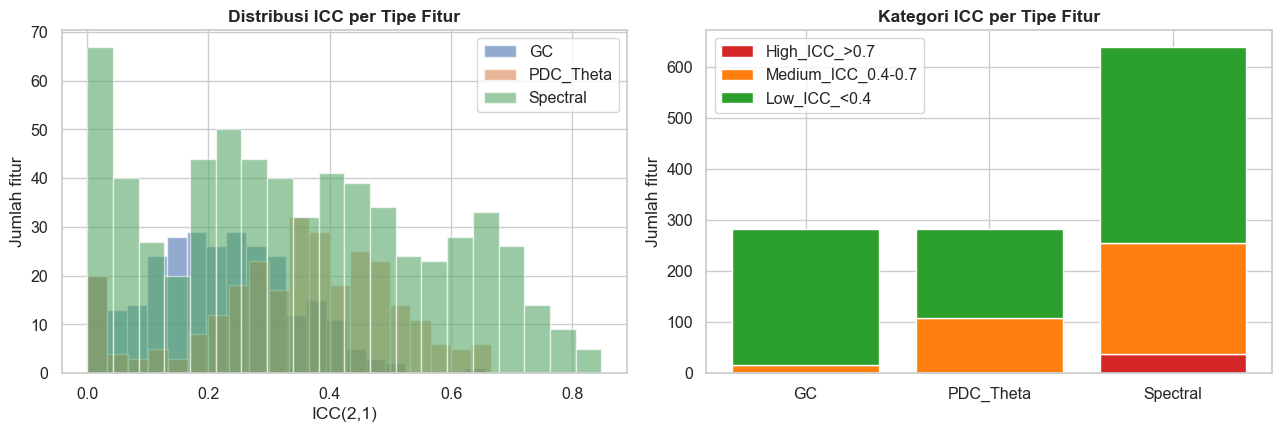

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel 1: histogram distribusi ICC per dataset
for name, color in zip(['GC', best_pdc_name, 'Spectral'], ['#4c72b0', '#dd8452', '#55a868']):
    axes[0].hist(icc_by_dataset[name]['icc'], bins=20, alpha=0.6, label=name, color=color)
axes[0].set_xlabel('ICC(2,1)')
axes[0].set_ylabel('Jumlah fitur')
axes[0].set_title('Distribusi ICC per Tipe Fitur', fontweight='bold')
axes[0].legend()

# Panel 2: stacked bar high/medium/low ICC count
cats = ['High_ICC_>0.7', 'Medium_ICC_0.4-0.7', 'Low_ICC_<0.4']
bottom = np.zeros(len(df_icc_summary))
colors2 = ['#d62728', '#ff7f0e', '#2ca02c']
for cat, c in zip(cats, colors2):
    axes[1].bar(df_icc_summary['Dataset'], df_icc_summary[cat], bottom=bottom, label=cat, color=c)
    bottom += df_icc_summary[cat].values
axes[1].set_ylabel('Jumlah fitur')
axes[1].set_title('Kategori ICC per Tipe Fitur', fontweight='bold')
axes[1].legend()

plt.tight_layout()
fig.savefig(os.path.join(DIR_55_FIG, '5.5_icc_distribution.png'), dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

**Kesimpulan 5.5:** **Spectral** paling subject-dependent (37 fitur ICC>0.7, mean ICC 0.344)
dibanding **GC** (0 fitur ICC>0.7, mean ICC 0.217) dan **PDC** (mean ICC 0.347, tapi lebih banyak
fitur medium daripada high). Artinya baseline individu (mis. amplitudo power spektral dasar
seseorang) paling berpengaruh ke fitur spektral -- relevan karena Spectral adalah kontributor
akurasi utama (temuan Langkah 3/Phase 4). Ini menjadi motivasi kuantitatif untuk ablasi
subject-wise normalization di **5.6**.